# META-SGD Model

Running on CPU  |  Seed: 11

Upload 3 CSV files: train (augmented), validation, test


Saving test_set_scaled.csv to test_set_scaled (2).csv
Saving validation_set_scaled.csv to validation_set_scaled (2).csv
Saving preprocessed_augmented_dataset_scaled.csv to preprocessed_augmented_dataset_scaled (2).csv
Train: preprocessed_augmented_dataset_scaled (2).csv
Val:   validation_set_scaled (2).csv
Test:  test_set_scaled (2).csv

Features: 19  |  Classes: 10
Train: 100000  Val: 320  Test: 330
Parameters: 106,826

Training (max 5 epochs, patience 5)



Epoch 1/5:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch   1 | train=0.8475 | val=0.9469 | gap=-0.0993 | lr=2.7e-04


Epoch 2/5:   0%|          | 0/782 [00:00<?, ?it/s]

...

Epoch   3 | train=0.9884 | val=0.9531 | gap=+0.0353 | lr=1.0e-04


Epoch 4/5:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch   4 | train=0.9969 | val=0.9531 | gap=+0.0438 | lr=3.0e-05


Epoch 5/5:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch   5 | train=1.0000 | val=0.9500 | gap=+0.0500 | lr=1.0e-06

Best validation accuracy: 0.9594

FINAL META SGD PERFORMANCE (Optimized: Dropout Removed)
Accuracy : 0.9455 (94.55%)
Precision: 0.9484
Recall   : 0.9455
F1 Score : 0.9448

Ablation benchmark comparison:
  Baseline (with dropout=0.15) : 93.33%
  Optimized (dropout=0.0)      : 94.55%
  Improvement: +1.22%


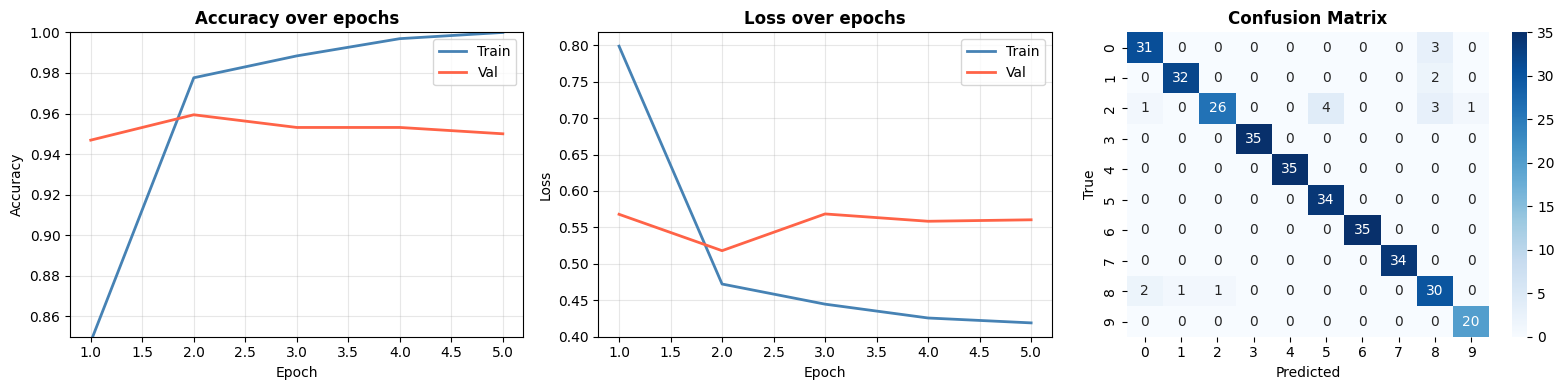


✅ Evaluation plot saved as: meta_sgd_final_results.png

Classification Report:
              precision    recall  f1-score   support

           0     0.9118    0.9118    0.9118        34
           1     0.9697    0.9412    0.9552        34
           2     0.9630    0.7429    0.8387        35
           3     1.0000    1.0000    1.0000        35
           4     1.0000    1.0000    1.0000        35
           5     0.8947    1.0000    0.9444        34
           6     1.0000    1.0000    1.0000        35
           7     1.0000    1.0000    1.0000        34
           8     0.7895    0.8824    0.8333        34
           9     0.9524    1.0000    0.9756        20

    accuracy                         0.9455       330
   macro avg     0.9481    0.9478    0.9459       330
weighted avg     0.9484    0.9455    0.9448       330


Model saved to: /content/meta_sgd_final.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


FINAL MODEL READY
Architecture: d_model=64, heads=4, layers=3, dropout=0.0
Test Accuracy: 94.55%
Test F1 Score: 0.9448


In [ ]:
# ============================================================
# FINAL META SGD TRANSFORMER MODEL
# Optimized via comprehensive ablation studies
# ============================================================
# !pip -q install torch pandas numpy scikit-learn tqdm matplotlib

import copy
import random
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.utils.class_weight import compute_class_weight
from tqdm.auto import tqdm
from google.colab import files

warnings.filterwarnings('ignore')

# ============================================================
# 1. CONFIGURATION (Optimal from Ablation)
# ============================================================
TARGET_COL   = "fault_encoded"
SEED         = 11

# Model architecture (all kept at baseline)
D_MODEL      = 64
N_HEADS      = 4
N_LAYERS     = 3
DROPOUT      = 0.0                    # REMOVED per ablation (best result)

# Training settings (all kept at baseline)
BATCH_SIZE   = 128
EPOCHS       = 5
PATIENCE     = 5
LR           = 3e-4
LR_MIN       = 1e-6
WEIGHT_DECAY = 3e-4
LABEL_SMOOTH = 0.08
GRAD_CLIP    = 2.0

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(SEED)
DEVICE = torch.device("cpu")
print(f"Running on CPU  |  Seed: {SEED}")

# ============================================================
# 2. UPLOAD DATA (Colab)
# ============================================================
print("\nUpload 3 CSV files: train (augmented), validation, test")
uploaded = files.upload()
names = list(uploaded.keys())

def pick(role):
    kw = {
        "train": ["augmented", "train", "training", "preprocessed"],
        "val":   ["val", "validation"],
        "test":  ["test"],
    }
    hits = [f for f in names if any(k in f.lower() for k in kw[role])]
    if len(hits) == 1:
        return hits[0]
    for i, f in enumerate(names):
        print(f"  {i}: {f}")
    return names[int(input(f"Enter index for {role} file: "))]

train_file, val_file, test_file = pick("train"), pick("val"), pick("test")
print(f"Train: {train_file}\nVal:   {val_file}\nTest:  {test_file}")

# ============================================================
# 3. LOAD AND PREPARE DATA
# ============================================================
train_df = pd.read_csv(train_file)
val_df   = pd.read_csv(val_file)
test_df  = pd.read_csv(test_file)

if TARGET_COL not in train_df.columns:
    print("Available columns:", list(train_df.columns))
    TARGET_COL = input("Enter target column name: ")

feat_cols = [c for c in train_df.columns if c != TARGET_COL]

for df in [train_df, val_df, test_df]:
    df[feat_cols] = df[feat_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

le = LabelEncoder()
le.fit(pd.concat([train_df[TARGET_COL], val_df[TARGET_COL], test_df[TARGET_COL]]))

X_tr = train_df[feat_cols].values.astype(np.float32)
y_tr = le.transform(train_df[TARGET_COL])
X_va = val_df[feat_cols].values.astype(np.float32)
y_va = le.transform(val_df[TARGET_COL])
X_te = test_df[feat_cols].values.astype(np.float32)
y_te = le.transform(test_df[TARGET_COL])

n_feat    = X_tr.shape[1]
n_classes = len(le.classes_)
print(f"\nFeatures: {n_feat}  |  Classes: {n_classes}")
print(f"Train: {len(X_tr)}  Val: {len(X_va)}  Test: {len(X_te)}")

# Scale features
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_va_sc = scaler.transform(X_va)
X_te_sc = scaler.transform(X_te)

def to_t(X, y):
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

X_tr_t, y_tr_t = to_t(X_tr_sc, y_tr)
X_va_t, y_va_t = to_t(X_va_sc, y_va)
X_te_t, y_te_t = to_t(X_te_sc, y_te)

# Balanced sampler
cw_np = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
sw = torch.tensor(cw_np[y_tr], dtype=torch.float32)
sampler = WeightedRandomSampler(sw, len(sw), replacement=True)

train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=BATCH_SIZE, sampler=sampler, num_workers=0)
val_loader   = DataLoader(TensorDataset(X_va_t, y_va_t), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(TensorDataset(X_te_t, y_te_t), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# ============================================================
# 4. MODEL DEFINITION (Dropout removed)
# ============================================================
class FaultTransformer(nn.Module):
    """
    Transformer with dropout removed per ablation study.
    Each feature becomes a token; self-attention learns feature interactions.
    """

    def __init__(self, n_feat, n_classes, d_model, n_heads, n_layers, dropout):
        super().__init__()
        self.embed    = nn.Linear(1, d_model)
        self.pos      = nn.Parameter(torch.randn(1, n_feat, d_model) * 0.01)
        # dropout=0 -> this layer is effectively a no-op
        self.drop_in  = nn.Dropout(dropout)

        layer = nn.TransformerEncoderLayer(
            d_model         = d_model,
            nhead           = n_heads,
            dim_feedforward = d_model * 2,
            dropout         = dropout,        # dropout=0
            activation      = 'gelu',
            batch_first     = True,
            norm_first      = True,
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.norm_out = nn.LayerNorm(d_model)

        self.head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),               # dropout=0
            nn.Linear(d_model, n_classes),
        )

    def forward(self, x):
        x = x.unsqueeze(-1)
        x = self.embed(x) + self.pos
        x = self.drop_in(x)
        x = self.encoder(x)
        x = self.norm_out(x)
        x = x.mean(dim=1)
        return self.head(x)

model = FaultTransformer(n_feat, n_classes, D_MODEL, N_HEADS, N_LAYERS, DROPOUT)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters: {n_params:,}")

# ============================================================
# 5. TRAIN FINAL MODEL
# ============================================================
def train_final(model):
    cw = torch.tensor(cw_np, dtype=torch.float32)
    criterion = nn.CrossEntropyLoss(
        weight=cw,
        label_smoothing=LABEL_SMOOTH
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=EPOCHS,
        eta_min=LR_MIN
    )

    best_acc = 0.0
    best_state = None
    wait = 0

    train_accs, val_accs = [], []
    train_losses, val_losses = [], []

    print(f"\nTraining (max {EPOCHS} epochs, patience {PATIENCE})\n")

    for epoch in range(1, EPOCHS + 1):
        # Training
        model.train()
        tp, tl = [], []
        tloss = 0.0

        pbar = tqdm(train_loader, total=len(train_loader),
                    desc=f"Epoch {epoch}/{EPOCHS}", leave=True)

        for xb, yb in pbar:
            optimizer.zero_grad(set_to_none=True)

            out = model(xb)
            loss = criterion(out, yb)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()

            tloss += loss.item()
            tp.extend(out.argmax(1).detach().numpy())
            tl.extend(yb.numpy())

            pbar.set_postfix(loss=f"{loss.item():.6f}")

        scheduler.step()

        train_loss = tloss / len(train_loader)
        train_losses.append(train_loss)

        train_acc = accuracy_score(tl, tp)
        train_accs.append(train_acc)

        # Validation
        model.eval()
        vp, vl = [], []
        vloss = 0.0

        with torch.no_grad():
            for xb, yb in val_loader:
                out = model(xb)
                loss = criterion(out, yb)
                vloss += loss.item()
                vp.extend(out.argmax(1).numpy())
                vl.extend(yb.numpy())

        val_loss = vloss / len(val_loader)
        val_losses.append(val_loss)

        val_acc = accuracy_score(vl, vp)
        val_accs.append(val_acc)

        gap = train_acc - val_acc

        print(
            f"Epoch {epoch:>3} | "
            f"train={train_acc:.4f} | "
            f"val={val_acc:.4f} | "
            f"gap={gap:+.4f} | "
            f"lr={optimizer.param_groups[0]['lr']:.1e}"
        )

        if val_acc > best_acc:
            best_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= PATIENCE:
                print(f"\nEarly stopping at epoch {epoch}")
                break

    model.load_state_dict(best_state)
    print(f"\nBest validation accuracy: {best_acc:.4f}")

    return train_accs, val_accs, train_losses, val_losses

train_accs, val_accs, train_losses, val_losses = train_final(model)

# ============================================================
# 6. EVALUATE ON TEST SET
# ============================================================
def evaluate(model, loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            preds.extend(model(xb).argmax(1).numpy())
            labels.extend(yb.numpy())
    return {
        'accuracy':  accuracy_score(labels, preds),
        'precision': precision_score(labels, preds, average='weighted', zero_division=0),
        'recall':    recall_score(labels, preds, average='weighted', zero_division=0),
        'f1':        f1_score(labels, preds, average='weighted', zero_division=0),
        'preds':     preds,
        'labels':    labels,
    }

test_metrics = evaluate(model, test_loader)

print("\n" + "=" * 80)
print("FINAL META SGD PERFORMANCE (Optimized: Dropout Removed)")
print("=" * 80)
print(f"Accuracy : {test_metrics['accuracy']:.4f} ({test_metrics['accuracy'] * 100:.2f}%)")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall   : {test_metrics['recall']:.4f}")
print(f"F1 Score : {test_metrics['f1']:.4f}")
print("=" * 80)

print("\nAblation benchmark comparison:")
print(f"  Baseline (with dropout=0.15) : 93.33%")
print(f"  Optimized (dropout=0.0)      : {test_metrics['accuracy']*100:.2f}%")
print(f"  Improvement: +{(test_metrics['accuracy'] - 0.9333)*100:.2f}%")

# ============================================================
# 7. VISUALIZATIONS
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Accuracy curves
ep = range(1, len(train_accs) + 1)
axes[0].plot(ep, train_accs, label='Train', color='steelblue', lw=2)
axes[0].plot(ep, val_accs, label='Val', color='tomato', lw=2)
axes[0].set_title('Accuracy over epochs', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.85, 1.0)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss curves
axes[1].plot(ep, train_losses, label='Train', color='steelblue', lw=2)
axes[1].plot(ep, val_losses, label='Val', color='tomato', lw=2)
axes[1].set_title('Loss over epochs', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Confusion matrix
cm = confusion_matrix(test_metrics['labels'], test_metrics['preds'])
class_names = [str(c) for c in le.classes_]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[2])
axes[2].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('True')

plt.tight_layout()
plt.savefig("meta_sgd_final_results.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Evaluation plot saved as: meta_sgd_final_results.png")

# ============================================================
# 8. PRINT CLASSIFICATION REPORT
# ============================================================
print("\nClassification Report:")
print(classification_report(test_metrics['labels'], test_metrics['preds'],
                            target_names=class_names, digits=4))

# ============================================================
# 9. SAVE AND DOWNLOAD FINAL MODEL
# ============================================================
save_path = "/content/meta_sgd_final.pth"
torch.save({
    'model_state_dict': model.state_dict(),
    'test_metrics':     test_metrics,
    'feature_cols':     feat_cols,
    'label_classes':    list(le.classes_),
    'n_features':       n_feat,
    'n_classes':        n_classes,
    'scaler':           scaler,
    'config': {
        'd_model':  D_MODEL,
        'n_heads':  N_HEADS,
        'n_layers': N_LAYERS,
        'dropout':  DROPOUT,
        'batch_size': BATCH_SIZE,
        'lr': LR,
        'weight_decay': WEIGHT_DECAY,
        'label_smoothing': LABEL_SMOOTH,
        'grad_clip': GRAD_CLIP,
    },
    'ablation_best': 'dropout_removed'
}, save_path)

print(f"\nModel saved to: {save_path}")
files.download(save_path)

print("\n" + "=" * 80)
print("FINAL MODEL READY")
print("=" * 80)
print(f"Architecture: d_model={D_MODEL}, heads={N_HEADS}, layers={N_LAYERS}, dropout={DROPOUT}")
print(f"Test Accuracy: {test_metrics['accuracy']*100:.2f}%")
print(f"Test F1 Score: {test_metrics['f1']:.4f}")
print("=" * 80)